# Pipeline

- BANDPASS -> CSP -> LDA

- Mean Accuracy: 53.5 %

# Load the Data

In [49]:
import numpy as np

data = np.load("Datasets/Main.npz")
X = data["X_raw"]
y = data["y"]  

BAD_CHANNELS = [0,1,2,6,7]
X = np.delete(X, BAD_CHANNELS, axis=1)
print(X.shape)

import numpy as np
from brainflow.data_filter import (
    DataFilter,
    FilterTypes,
    DetrendOperations
)

SAMPLING_RATE = 250  
LOW_CUT = 8
HIGH_CUT = 13
FILTER_ORDER = 4

X_filtered = np.copy(X)

for trial in range(X.shape[0]):

    for ch in range(X.shape[1]):

        signal = X_filtered[trial, ch]
        signal = np.ascontiguousarray(
            signal,
            dtype=np.float64
        )

        # Remove DC offset
        DataFilter.detrend(
            signal,
            DetrendOperations.CONSTANT.value
        )

        # 3–45 Hz Bandpass
        DataFilter.perform_bandpass(
            signal,
            SAMPLING_RATE,
            LOW_CUT,
            HIGH_CUT,
            FILTER_ORDER,
            FilterTypes.BUTTERWORTH_ZERO_PHASE.value,
            0
        )

        DataFilter.remove_environmental_noise(
            signal,
            SAMPLING_RATE,
            1
        )

        X_filtered[trial, ch] = signal

print("Original Shape :", X.shape)
print("Filtered Shape :", X_filtered.shape)

X = X_filtered

X_snipped = X[:, :, 500:-250]
X = X_snipped
print("Original Shape :", X.shape)
print("Snipped Shape  :", X_snipped.shape)

(480, 3, 1750)
Original Shape : (480, 3, 1750)
Filtered Shape : (480, 3, 1750)
Original Shape : (480, 3, 1000)
Snipped Shape  : (480, 3, 1000)


## Z Peaks Rejection

In [50]:
import numpy as np
from brainflow.data_filter import DataFilter

spike_thresh = 15
z_threshold = 4.0
lag = 50
influence = 0.0

good_trials = []
bad_trials = []

for i in range(X.shape[0]):
    trial_bad = False

    for ch in range(X.shape[1]):
        sig = X[i, ch]

        peaks = DataFilter.detect_peaks_z_score(
            sig,
            lag=lag,
            threshold=z_threshold,
            influence=influence
        )

        spike_count = np.sum(peaks != 0)

        if spike_count > spike_thresh:
            trial_bad = True
            break

    if trial_bad:
        bad_trials.append(i)
    else:
        good_trials.append(i)

good_trials = np.array(good_trials)
bad_trials = np.array(bad_trials)

X_clean = X[good_trials]
y_clean = y[good_trials]

print("Original X:", X.shape)
print("Clean X:", X_clean.shape)
print("Kept:", len(good_trials))
print("Rejected:", len(bad_trials))
print("Bad trial indices:", bad_trials)

X = X_clean
y = y_clean

Original X: (480, 3, 1000)
Clean X: (476, 3, 1000)
Kept: 476
Rejected: 4
Bad trial indices: [108 159 223 437]


## Plot Pre CSP

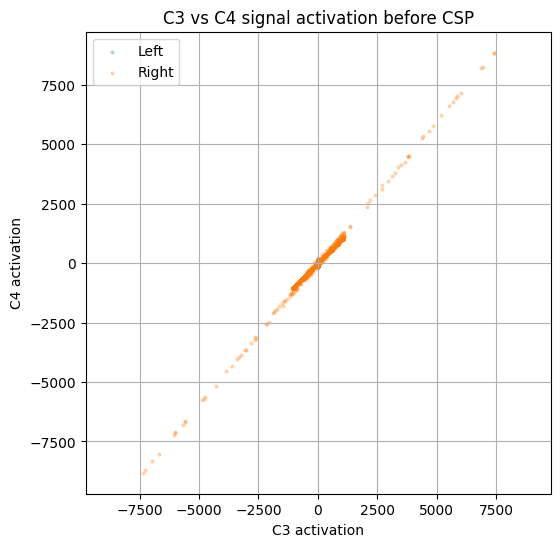

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# X shape: (trials, channels, samples)
# y shape: (trials,) labels, e.g. 0 = left, 1 = right

C3_IDX = 0 
C4_IDX = 2 

LEFT = 1
RIGHT = 2

plt.figure(figsize=(6, 6))

for label, name in [(LEFT, "Left"), (RIGHT, "Right")]:
    X_class = X[y == label]  # shape: (class_trials, 3, 750)

    c3 = X_class[:, C3_IDX, :].reshape(-1)
    c4 = X_class[:, C4_IDX, :].reshape(-1)

    plt.scatter(c3, c4, s=4, alpha=0.25, label=name)

plt.xlabel("C3 activation")
plt.ylabel("C4 activation")
plt.title("C3 vs C4 signal activation before CSP")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# CSP Activation

In [52]:
import numpy as np
from brainflow.data_filter import DataFilter

LEFT = 1
RIGHT = 2

y_csp = np.zeros_like(y, dtype=np.float64)
y_csp[y == RIGHT] = 1.0

mask = (y == LEFT) | (y == RIGHT)

X_bf = np.ascontiguousarray(X[mask], dtype=np.float64)
y_bf = np.ascontiguousarray(y_csp[mask], dtype=np.float64)
filters, eigenvalues = DataFilter.get_csp(X_bf, y_bf)

X_csp_signal = np.array([
    filters @ trial
    for trial in X_bf
])

print("X_csp_signal:", X_csp_signal.shape)

X = X_csp_signal
y = y_bf

X_csp_signal: (476, 3, 1000)


In [53]:
eigenvalues

array([0.02230973, 0.22677461, 0.46396963])

# Post CSP Plot

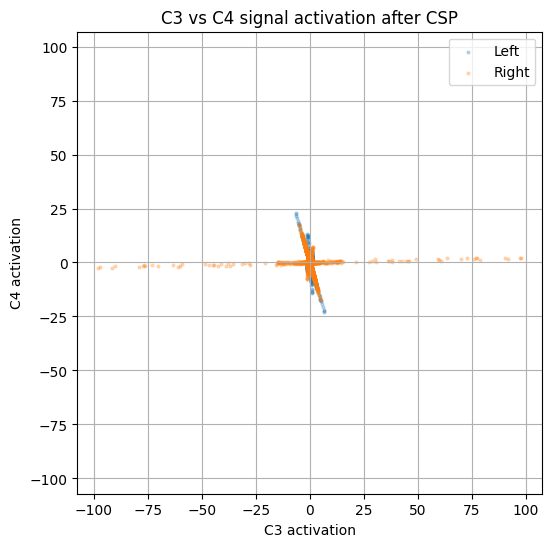

In [54]:
import numpy as np
import matplotlib.pyplot as plt

C3_IDX = 0   
C4_IDX = 2

LEFT = 0
RIGHT = 1

plt.figure(figsize=(6, 6))

for label, name in [(LEFT, "Left"), (RIGHT, "Right")]:
    X_class = X[y == label]  # shape: (class_trials, 3, 750)

    c3 = X_class[:, C3_IDX, :].reshape(-1)
    c4 = X_class[:, C4_IDX, :].reshape(-1)

    plt.scatter(c3, c4, s=4, alpha=0.25, label=name)

plt.xlabel("C3 activation")
plt.ylabel("C4 activation")
plt.title("C3 vs C4 signal activation after CSP")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# LDA

Fold 1 | Accuracy: 0.4896 | Log Loss: 0.6921
Fold 2 | Accuracy: 0.4000 | Log Loss: 0.6933
Fold 3 | Accuracy: 0.3684 | Log Loss: 0.6989
Fold 4 | Accuracy: 0.4947 | Log Loss: 0.6977
Fold 5 | Accuracy: 0.5053 | Log Loss: 0.6940

CV scores: [0.48958333 0.4        0.36842105 0.49473684 0.50526316]
Mean accuracy: 0.4516008771929824
Std accuracy : 0.05615078370714374
Best fold    : 0.5052631578947369
Worst fold   : 0.3684210526315789
Mean log loss: 0.6952210123592278
Std log loss : 0.002643249496429826


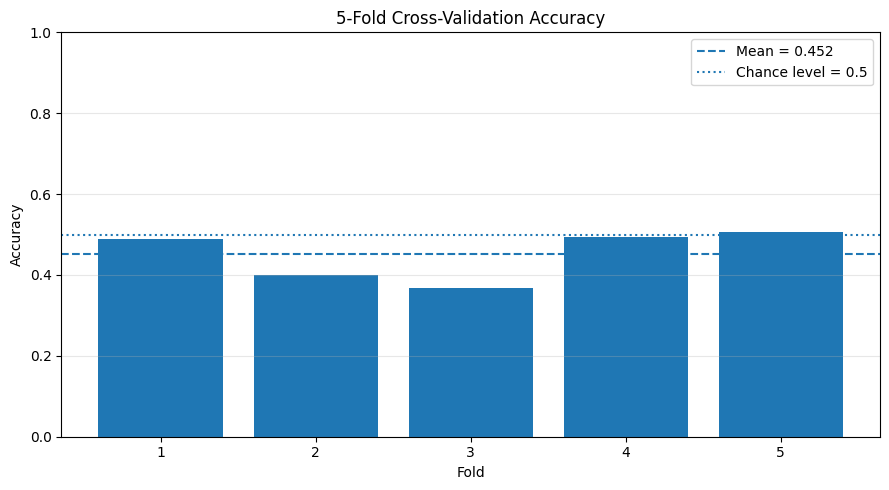

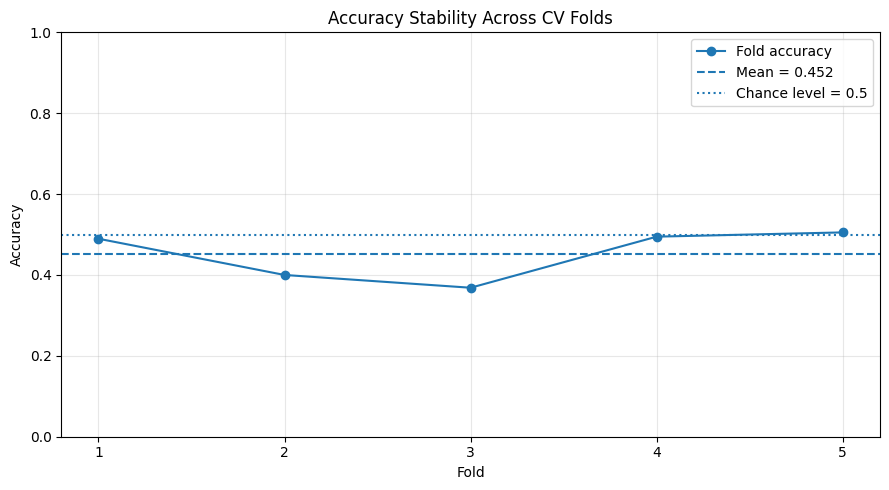

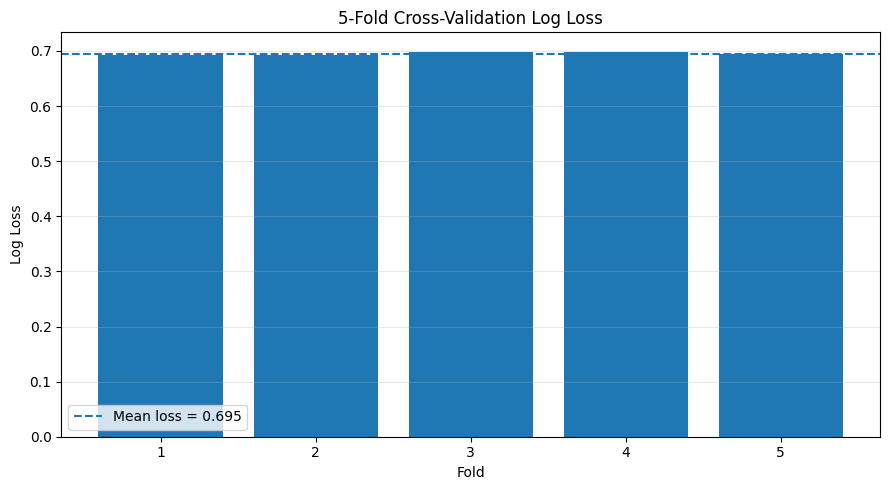

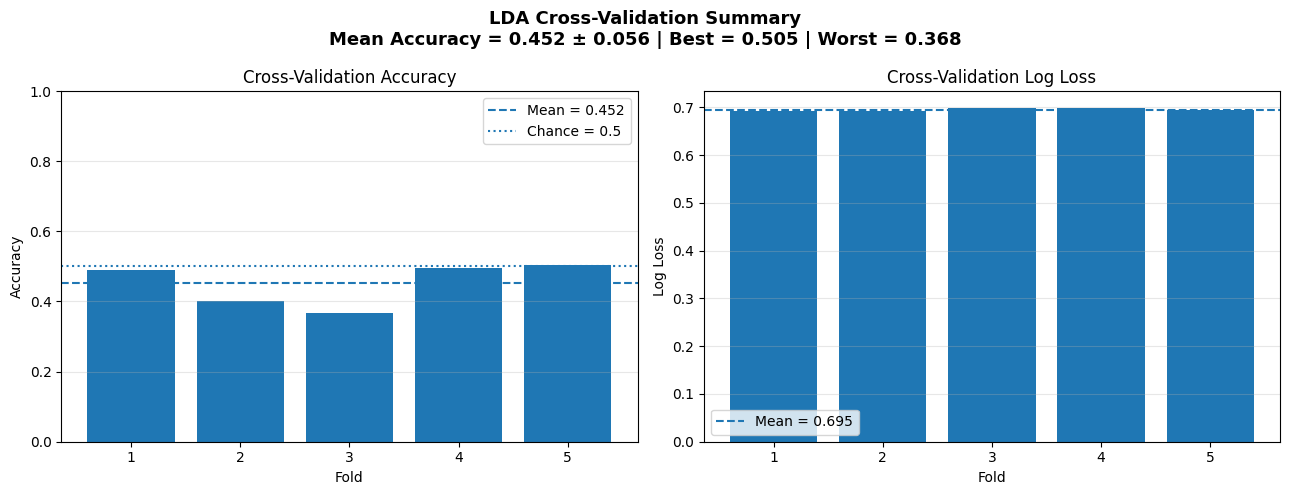

In [55]:
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, log_loss

import numpy as np
import matplotlib.pyplot as plt

# =========================
# FEATURE EXTRACTION
# =========================
var = np.var(X, axis=2)
var = np.where(var == 0, 1e-12, var)
features = np.log(var)

# =========================
# MODEL
# =========================
lda = LinearDiscriminantAnalysis(
    solver="eigen",
    shrinkage="auto"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================
# CROSS VALIDATION MANUAL LOOP
# =========================
fold_accuracies = []
fold_losses = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(features, y), start=1):
    X_train, X_test = features[train_idx], features[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    lda.fit(X_train, y_train)

    y_pred = lda.predict(X_test)
    y_proba = lda.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_proba)

    fold_accuracies.append(acc)
    fold_losses.append(loss)

    print(f"Fold {fold_idx} | Accuracy: {acc:.4f} | Log Loss: {loss:.4f}")

fold_accuracies = np.array(fold_accuracies)
fold_losses = np.array(fold_losses)

print("\nCV scores:", fold_accuracies)
print("Mean accuracy:", np.mean(fold_accuracies))
print("Std accuracy :", np.std(fold_accuracies))
print("Best fold    :", np.max(fold_accuracies))
print("Worst fold   :", np.min(fold_accuracies))
print("Mean log loss:", np.mean(fold_losses))
print("Std log loss :", np.std(fold_losses))

# =========================
# PLOT 1: ACCURACY BAR PLOT
# =========================
folds = np.arange(1, len(fold_accuracies) + 1)

plt.figure(figsize=(9, 5))
plt.bar(folds, fold_accuracies)
plt.axhline(np.mean(fold_accuracies), linestyle="--", label=f"Mean = {np.mean(fold_accuracies):.3f}")
plt.axhline(0.5, linestyle=":", label="Chance level = 0.5")

plt.xticks(folds)
plt.ylim(0, 1)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cv_accuracy_bar.png", dpi=300)
plt.show()

# =========================
# PLOT 2: ACCURACY LINE PLOT
# =========================
plt.figure(figsize=(9, 5))
plt.plot(folds, fold_accuracies, marker="o", label="Fold accuracy")
plt.axhline(np.mean(fold_accuracies), linestyle="--", label=f"Mean = {np.mean(fold_accuracies):.3f}")
plt.axhline(0.5, linestyle=":", label="Chance level = 0.5")

plt.xticks(folds)
plt.ylim(0, 1)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Accuracy Stability Across CV Folds")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cv_accuracy_line.png", dpi=300)
plt.show()

# =========================
# PLOT 3: LOG LOSS BAR PLOT
# =========================
plt.figure(figsize=(9, 5))
plt.bar(folds, fold_losses)
plt.axhline(np.mean(fold_losses), linestyle="--", label=f"Mean loss = {np.mean(fold_losses):.3f}")

plt.xticks(folds)
plt.xlabel("Fold")
plt.ylabel("Log Loss")
plt.title("5-Fold Cross-Validation Log Loss")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cv_loss_bar.png", dpi=300)
plt.show()

# =========================
# PLOT 4: DOCUMENTATION DASHBOARD
# =========================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy panel
axes[0].bar(folds, fold_accuracies)
axes[0].axhline(np.mean(fold_accuracies), linestyle="--", label=f"Mean = {np.mean(fold_accuracies):.3f}")
axes[0].axhline(0.5, linestyle=":", label="Chance = 0.5")
axes[0].set_xticks(folds)
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Cross-Validation Accuracy")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Loss panel
axes[1].bar(folds, fold_losses)
axes[1].axhline(np.mean(fold_losses), linestyle="--", label=f"Mean = {np.mean(fold_losses):.3f}")
axes[1].set_xticks(folds)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Log Loss")
axes[1].set_title("Cross-Validation Log Loss")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle(
    f"LDA Cross-Validation Summary\n"
    f"Mean Accuracy = {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f} | "
    f"Best = {np.max(fold_accuracies):.3f} | Worst = {np.min(fold_accuracies):.3f}",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("cv_summary_dashboard.png", dpi=300)
plt.show()